In [1]:
import cftime
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

In [2]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

In [3]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

## Investigate Miocene dust ERF under Preindustrial Boundary Condition
### Analysis: (6~30 yr.) mean

In [4]:
ds_Pi = xr.open_dataset('./Fig3_fSST_GeoPI_TOA.nc')


# read TOA-related data

PP_net_ano = ds_Pi['PI_NetTOA_ano']
PP_net_cloud_ano = ds_Pi['PI_TOA_cloud_ano']
PP_net_clear_ano = ds_Pi['PI_TOA_clear_ano']
PP_swc_ano = ds_Pi['PI_TOA_SW_clear_ano']
PP_lwc_ano = ds_Pi['PI_TOA_LW_clear_ano']

PP_net_ano_yr = ds_Pi['PI_NetTOA_ano_annual']
PP_net_cloud_ano_yr = ds_Pi['PI_TOA_cloud_ano_annual']
PP_net_clear_ano_yr = ds_Pi['PI_TOA_clear_ano_annual']
PP_swc_ano_yr = ds_Pi['PI_TOA_SW_clear_ano_annual']
PP_lwc_ano_yr = ds_Pi['PI_TOA_LW_clear_ano_annual']


# read surface albedo data

PP_albedo = ds_Pi['PI_albedo']
PP_albedo_ano = ds_Pi['PI_albedo_ano']


In [5]:
pattern_PP = np.empty((6, lat.size, lon.size))
pattern_PP = xr.DataArray(data=pattern_PP, dims=['var','lat','lon'], coords=[np.arange(1,6.5,1), lat, lon])

pattern_PP[0,:,:] = PP_net_ano
pattern_PP[1,:,:] = PP_swc_ano
pattern_PP[2,:,:] = PP_net_clear_ano
pattern_PP[3,:,:] = PP_lwc_ano
pattern_PP[4,:,:] = PP_net_cloud_ano
pattern_PP[5,:,:] = PP_albedo

pattern_PP

<xarray.DataArray (var: 6, lat: 96, lon: 144)>
array([[[ 1.50794506e-01,  1.55526355e-01,  1.50938138e-01, ...,
          1.46695375e-01,  1.50670111e-01,  1.52586743e-01],
        [ 1.09866507e-01,  1.14243269e-01,  1.13383584e-01, ...,
          1.17886275e-01,  1.09888256e-01,  1.11387968e-01],
        [ 4.33455668e-02,  8.02086890e-02,  8.18256363e-02, ...,
         -4.78947550e-01, -5.10054350e-01, -4.27929491e-01],
        ...,
        [ 6.77373946e-01,  7.16241181e-01,  7.94264615e-01, ...,
          5.32633305e-01,  5.53539455e-01,  5.93743980e-01],
        [ 1.87218750e+00,  1.84353173e+00,  1.87043798e+00, ...,
          1.89499998e+00,  1.87643981e+00,  1.85222590e+00],
        [ 3.52086425e+00,  3.60371757e+00,  3.68349767e+00, ...,
          3.61133981e+00,  3.52500010e+00,  3.47059202e+00]],

       [[ 6.21097125e-02,  6.81318790e-02,  6.22905977e-02, ...,
          5.72506972e-02,  6.22420236e-02,  6.43846393e-02],
        [ 1.09019481e-01,  1.10337779e-01,  1.05966419e-01, ...,
          1.23555809e-01,  1.13835044e-01,  1.14485070e-01],
        [ 1.09576553e-01,  1.61102787e-01,  1.66349888e-01, ...,
         -5.82426786e-01, -6.07215106e-01, -4.98551697e-01],
...
        [-1.77255169e-01, -1.95145309e-01, -2.08262280e-01, ...,
         -1.44644439e-01, -1.66017130e-01, -1.75904900e-01],
        [-2.34633639e-01, -2.61350721e-01, -2.73094624e-01, ...,
         -2.08320871e-01, -2.14081168e-01, -2.23537743e-01],
        [-3.50730360e-01, -3.58841658e-01, -3.68331879e-01, ...,
         -3.46255988e-01, -3.44354868e-01, -3.45427483e-01]],

       [[ 8.21102371e+01,  8.19254456e+01,  8.20621872e+01, ...,
          8.22978821e+01,  8.21311722e+01,  8.20547867e+01],
        [ 8.21440277e+01,  8.20244293e+01,  8.18986435e+01, ...,
          8.20238037e+01,  8.23152008e+01,  8.20386429e+01],
        [ 8.17343597e+01,  8.24040070e+01,  8.19411621e+01, ...,
          8.22159729e+01,  8.21884155e+01,  8.23635788e+01],
        ...,
        [ 7.72699890e+01,  7.72154770e+01,  7.71589508e+01, ...,
          7.74895096e+01,  7.73890152e+01,  7.73069916e+01],
        [ 7.72673340e+01,  7.72497406e+01,  7.72253113e+01, ...,
          7.73316040e+01,  7.73159943e+01,  7.72995529e+01],
        [ 7.58083191e+01,  7.57061386e+01,  7.55890274e+01, ...,
          7.60842438e+01,  7.59945221e+01,  7.58963242e+01]]])
Coordinates:
  * var      (var) float64 1.0 2.0 3.0 4.0 5.0 6.0
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

In [6]:
# Add cyclic point to data
data = pattern_PP
data, lons = add_cyclic_point(data, coord=lon)

data_albedo_Diff = PP_albedo_ano
data_albedo_Diff, lons = add_cyclic_point(data_albedo_Diff, coord=lon)

In [7]:
# --- calculate mean ---

net_PP_Diff_mean = PP_net_ano.weighted(weights).mean(dim=['lon','lat']) 
swc_PP_Diff_mean = PP_swc_ano.weighted(weights).mean(dim=['lon','lat']) 
lwc_PP_Diff_mean = PP_lwc_ano.weighted(weights).mean(dim=['lon','lat']) 
net_clear_PP_Diff_mean = PP_net_clear_ano.weighted(weights).mean(dim=['lon','lat']) 
net_cloud_PP_Diff_mean = PP_net_cloud_ano.weighted(weights).mean(dim=['lon','lat']) 

print('{:03.3f}'.format(net_PP_Diff_mean.values))
print('{:03.3f}'.format(swc_PP_Diff_mean.values))
print('{:03.3f}'.format(lwc_PP_Diff_mean.values))
print('{:03.3f}'.format(net_clear_PP_Diff_mean.values))
print('{:03.3f}'.format(net_cloud_PP_Diff_mean.values))

-0.006
0.125
-0.060
0.065
-0.071


In [8]:
# --- calculate std ---

net_PP_Diff_std = PP_net_ano_yr.std(dim=['year'])
swc_PP_Diff_std = PP_swc_ano_yr.std(dim=['year'])
lwc_PP_Diff_std = PP_lwc_ano_yr.std(dim=['year']) 
net_clear_PP_Diff_std = PP_net_clear_ano_yr.std(dim=['year']) 
net_cloud_PP_Diff_std = PP_net_cloud_ano_yr.std(dim=['year']) 

print('{:03.3f}'.format(net_PP_Diff_std.values))
print('{:03.3f}'.format(swc_PP_Diff_std.values))
print('{:03.3f}'.format(lwc_PP_Diff_std.values))
print('{:03.3f}'.format(net_clear_PP_Diff_std.values))
print('{:03.3f}'.format(net_cloud_PP_Diff_std.values))

0.153
0.104
0.111
0.114
0.161


''

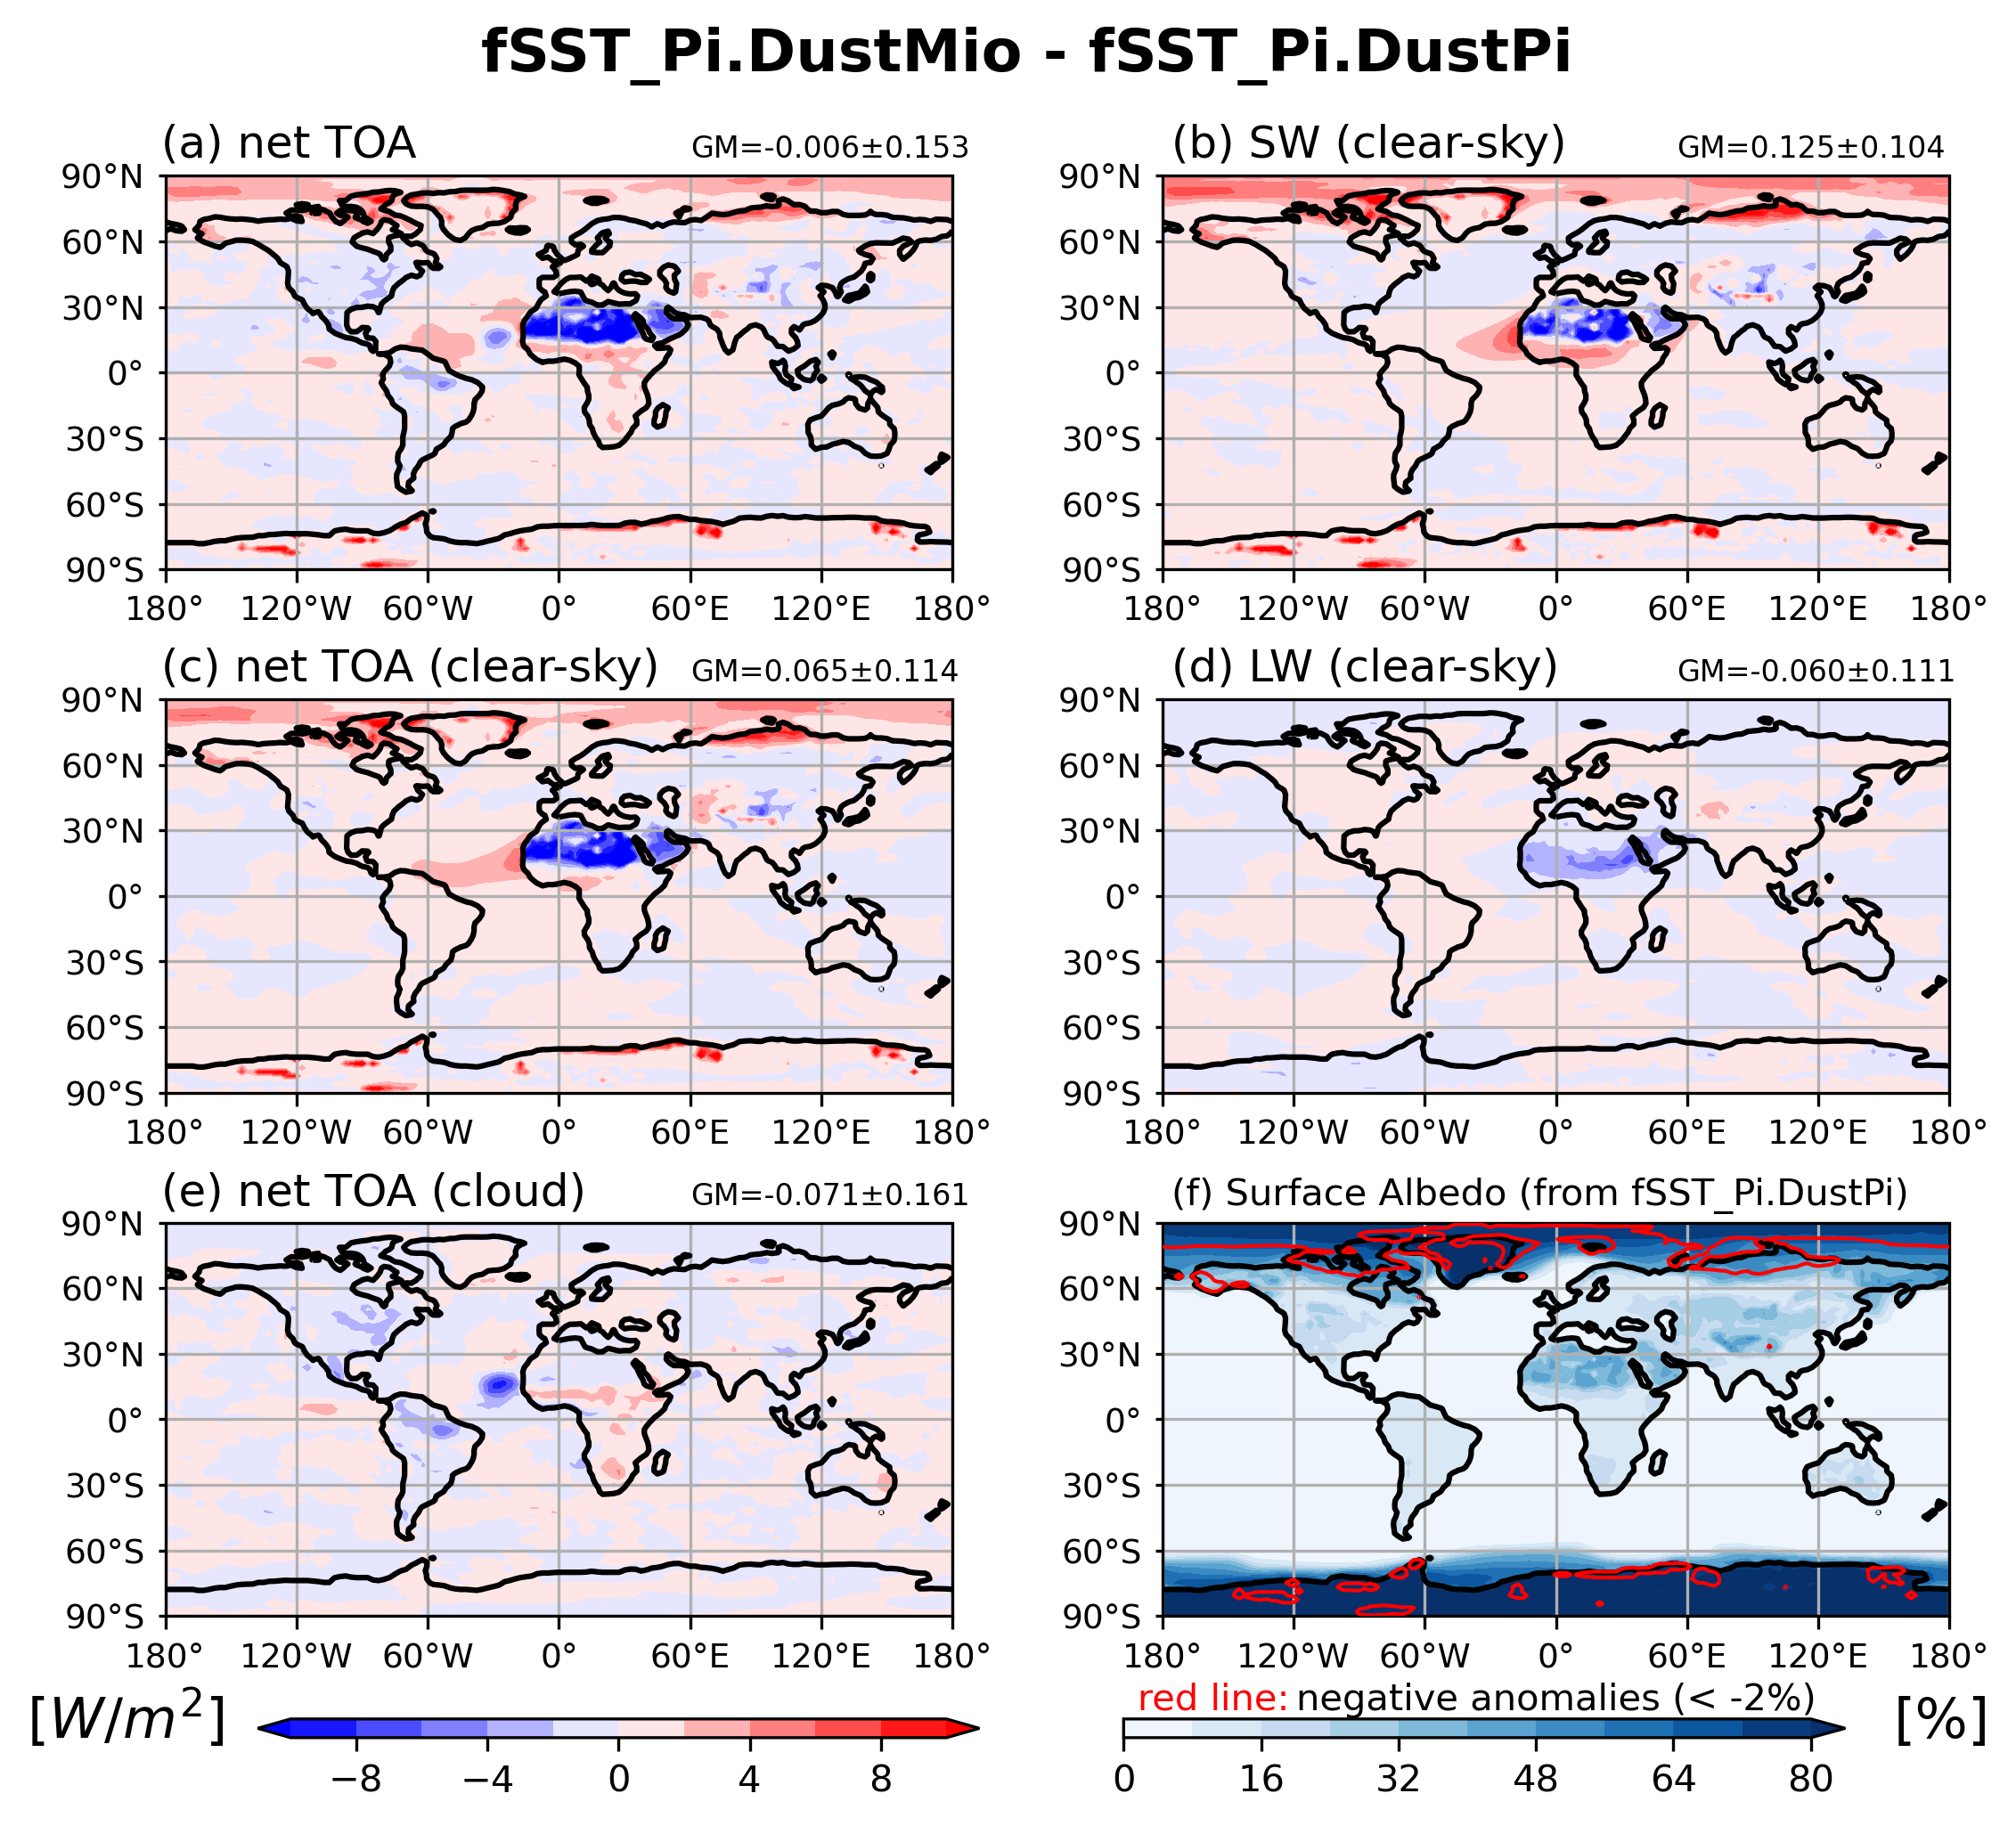

In [10]:
# --- setting: contours for albedo anomaly ---

levels_neg = np.linspace(-22, -2, 2)

# ===================================================================
# --- plot ---

# Define the figure and each axis for the 3 rows and 2 columns
fig, axs = plt.subplots(nrows=3,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                        figsize=(9,7), dpi=300)
    
# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.15, hspace=0.33) 
    
# axs is a 2 dimensional array of `GeoAxes`
# flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(pattern_PP['var']):
        
    # Contour plot
    if i==5:
        cs1=axs[i].contourf(lons,lat,data[i,:,:], levels = np.linspace(0, 80, 11),
                            transform = ccrs.PlateCarree(), cmap='Blues', extend='max')
        axs[i].contour(lons, lat, data_albedo_Diff, levels=levels_neg, colors='red',
                       linestyles='solid', linewidths=1.0, transform=ccrs.PlateCarree(), zorder=4) 
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)
    else:
        cs2=axs[i].contourf(lons,lat,data[i,:,:], levels = np.linspace(-10, 10, 11),
                            transform = ccrs.PlateCarree(), cmap='bwr', extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)

    # Longitude labels
    axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()  
    axs[i].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
    axs[i].tick_params(axis='y', size=2)             # set xtick parameters
    for xlabel in axs[i].get_xticklabels():          # set xticks_label
        xlabel.set_fontsize(9)        

    # Latitude labels
    axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
    lat_formatter = cticker.LatitudeFormatter()
    axs[i].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
    axs[i].tick_params(axis='y', size=2)             # set ytick parameters
    for ylabel in axs[i].get_yticklabels():          # set yticks_label
        ylabel.set_fontsize(9)        
        
          
    # Add gridlines
    axs[i].gridlines(colors='white', linewidths=0.2, zorder=2)
        
# Add colorbar
cax1 = fig.add_axes([0.54, 0.045, 0.3, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB1  = plt.colorbar(cs1, cax=cax1, orientation='horizontal')
cax2 = fig.add_axes([0.18, 0.045, 0.3, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB2  = plt.colorbar(cs2, cax=cax2, orientation='horizontal')
    
# Add colobar's title
GM_TOA = 'GM='+str('{:03.3f}'.format(net_PP_Diff_mean.values))+'±'+str('{:03.3f}'.format(net_PP_Diff_std.values))
GM_SWC = 'GM='+str('{:03.3f}'.format(swc_PP_Diff_mean.values))+'±'+str('{:03.3f}'.format(swc_PP_Diff_std.values))
GM_LWC = 'GM='+str('{:03.3f}'.format(lwc_PP_Diff_mean.values))+'±'+str('{:03.3f}'.format(lwc_PP_Diff_std.values))
GM_TOA_clear = 'GM='+str('{:03.3f}'.format(net_clear_PP_Diff_mean.values))+'±'+str('{:03.3f}'.format(net_clear_PP_Diff_std.values))
GM_TOA_cloud = 'GM='+str('{:03.3f}'.format(net_cloud_PP_Diff_mean.values))+'±'+str('{:03.3f}'.format(net_cloud_PP_Diff_std.values))

plt.figtext(0.125,0.045,'[$W/m^2$]',ha='center',fontsize=15)
plt.figtext(0.14,0.89,'(a) net TOA',fontsize=12)
plt.figtext(0.36,0.89,GM_TOA,fontsize=8)
plt.figtext(0.56,0.89,'(b) SW (clear-sky)',fontsize=12)
plt.figtext(0.77,0.89,GM_SWC,fontsize=8)
plt.figtext(0.14,0.61,'(c) net TOA (clear-sky)',fontsize=12)
plt.figtext(0.36,0.61,GM_TOA_clear,fontsize=8)
plt.figtext(0.56,0.61,'(d) LW (clear-sky)',fontsize=12)
plt.figtext(0.77,0.61,GM_LWC,fontsize=8)
plt.figtext(0.14,0.33,'(e) net TOA (cloud)',fontsize=12)
plt.figtext(0.36,0.33,GM_TOA_cloud,fontsize=8)
plt.figtext(0.56,0.33,'(f) Surface Albedo (from fSST_Pi.DustPi)',fontsize=10)
plt.figtext(0.88,0.045,'[%]',ha='center',fontsize=15)
plt.figtext(0.58,0.06,'red line: ',ha='center',fontsize=10, color='red')
plt.figtext(0.72,0.06,'negative anomalies (< -2%)',ha='center',fontsize=10)

# Add title
plt.suptitle('fSST_Pi.DustMio - fSST_Pi.DustPi', y=0.96, fontsize=16, weight='bold')
# fig.savefig('plot_TS.png')
;